# Customer Purchase Propensity Modeling
##
## Objective:
### Predict whether a customer will purchase after receiving a
### marketing campaign using demographic, behavioral and campaign
### related features.
##
## This notebook focuses on:
### 1. Data Understanding
### 2. Exploratory Data Analysis (EDA)
### 3. Data Cleaning
### 4. Data Preprocessing
### 5. Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('customer_propensity_data.csv')
df = df.drop("customer_id", axis=1)

In [3]:
df

,age,gender,marital_status,education,occupation,family_size,city,months_active,annual_income,website_visits_last_30d,...,previous_campaigns_received,previous_campaign_response_rate,total_orders,favorite_category,average_order_value,total_amount_spent,days_since_last_purchase,returned_orders,refund_requests,purchased
0,31,Male,Divorced,Master,Business,4,Mumbai,28,3497912.0,17,...,12,0.70,24,Electronics,17688.25,407894.28,128,1,1,0
1,18,Female,Single,Bachelor,Student,2,Kolkata,17,NaN,20,...,2,0.19,3,Groceries,615.91,1867.97,164,0,0,0
2,38,Female,Married,Master,Manager,3,Pune,49,2215467.0,23,...,18,0.66,59,Home Decor,4833.51,280173.13,58,10,4,1
3,39,Male,Widowed,Bachelor,Government,1,Pune,8,1132919.0,17,...,4,NaN,2,Sports,3120.05,6392.55,162,0,0,0
4,37,Female,Widowed,Master,Sales,2,Kolkata,50,976863.0,24,...,16,0.64,19,Home Decor,3205.91,59473.40,145,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50495,28,Female,Married,Diploma,Designer,4,Hyderabad,47,733073.0,21,...,15,0.67,28,Gaming,4848.49,130699.70,107,2,1,1
50496,28,Female,Single,Master,Marketing,1,Mumbai,33,1330191.0,15,...,8,0.60,13,Sports,4057.21,52632.20,156,0,0,1
50497,30,Female,Widowed,Bachelor,Government,1,Bangalore,59,862123.0,18,...,12,0.98,35,Beauty,1330.01,44571.52,119,4,1,1
50498,38,Female,Married,Master,Doctor,5,Chennai,52,2547565.0,19,...,16,0.70,55,Home Decor,4664.99,245015.89,109,6,1,1


In [4]:
df = df.copy()
pd.set_option('future.no_silent_downcasting', True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50500 entries, 0 to 50499
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              50500 non-null  int64  
 1   gender                           50500 non-null  object 
 2   marital_status                   50500 non-null  object 
 3   education                        50500 non-null  object 
 4   occupation                       50500 non-null  object 
 5   family_size                      50500 non-null  int64  
 6   city                             50500 non-null  object 
 7   months_active                    50500 non-null  int64  
 8   annual_income                    44697 non-null  float64
 9   website_visits_last_30d          50500 non-null  int64  
 10  app_sessions_last_30d            50500 non-null  int64  
 11  avg_session_duration             49870 non-null  float64
 12  pages_viewed      

In [6]:
df.duplicated().sum()

np.int64(421)

### Handling Missing Values

In [7]:
df = df.drop_duplicates()

In [8]:
df.isnull().sum()

age                                   0
gender                                0
marital_status                        0
education                             0
occupation                            0
family_size                           0
city                                  0
months_active                         0
annual_income                      5755
website_visits_last_30d               0
app_sessions_last_30d                 0
avg_session_duration                623
pages_viewed                          0
product_views                         0
categories_viewed                     0
search_count                          0
wishlist_items                     3005
cart_additions                        0
cart_abandonments                     0
campaign_channel                      0
campaign_type                         0
discount_percent                      0
personalized_offer                    0
campaign_duration_days                0
campaign_send_day                     0


In [9]:
df.loc[:, 'gender'] = df['gender'].replace({'Other': 'Unspecified', 'Unknown': 'Unspecified'})

In [10]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
imputer.fit(df[['avg_session_duration']])
df.loc[:, 'avg_session_duration'] = imputer.transform(df[['avg_session_duration']])

In [11]:
df.loc[:, "wishlist_items"] = df["wishlist_items"].fillna(0)

In [12]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
imputer.fit(df[['previous_campaign_response_rate']])
df.loc[:, 'previous_campaign_response_rate'] = imputer.transform(df[['previous_campaign_response_rate']])

In [13]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(df[['annual_income']])
df.loc[:, 'annual_income'] = imputer.transform(df[['annual_income']])

In [14]:
df.isnull().sum()

age                                0
gender                             0
marital_status                     0
education                          0
occupation                         0
family_size                        0
city                               0
months_active                      0
annual_income                      0
website_visits_last_30d            0
app_sessions_last_30d              0
avg_session_duration               0
pages_viewed                       0
product_views                      0
categories_viewed                  0
search_count                       0
wishlist_items                     0
cart_additions                     0
cart_abandonments                  0
campaign_channel                   0
campaign_type                      0
discount_percent                   0
personalized_offer                 0
campaign_duration_days             0
campaign_send_day                  0
campaign_send_hour                 0
holiday_campaign                   0
c

<Axes: xlabel='purchased', ylabel='count'>

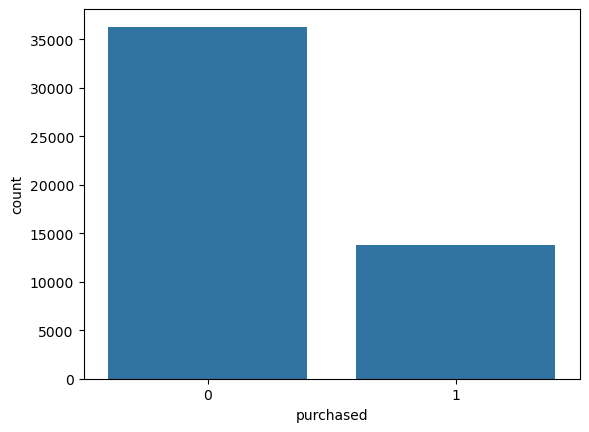

In [15]:
sns.countplot(x = 'purchased', data=df)

<Axes: xlabel='purchased', ylabel='age'>

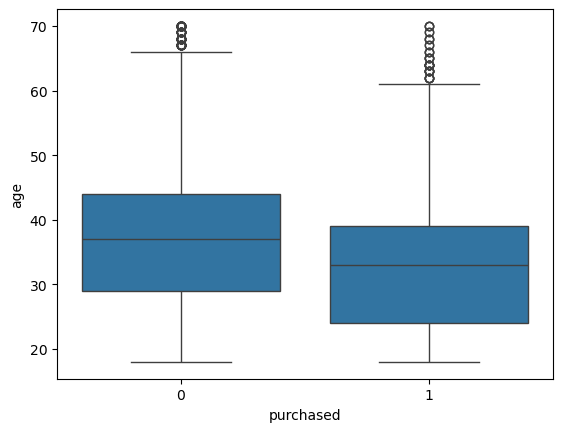

In [16]:
sns.boxplot(x = 'purchased', y = 'age', data=df)

<Axes: xlabel='purchased', ylabel='discount_percent'>

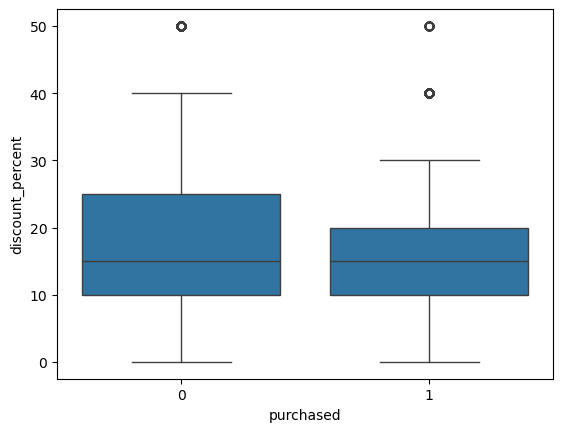

In [17]:
sns.boxplot(
    x='purchased',
    y='discount_percent',
    data=df
)

### Feature Engineering

In [18]:
df["purchase_frequency"] = (
    df["total_orders"] /
    df["months_active"]
).round(2)

In [19]:
df["avg_monthly_spend"] = (
    df["total_amount_spent"] /
    df["months_active"]
).round(2)

In [20]:
df["cart_abandonment_rate"] = (
    df["cart_abandonments"] /
    (df["cart_abandonments"] + df["total_orders"] + 1)
).round(3)

In [21]:
df["purchase_conversion_rate"] = (
    df["total_orders"] /
    (df["website_visits_last_30d"] + 1)
).round(3)

In [22]:
df["browsing_to_purchase_ratio"] = (
    df["product_views"] /
    (df["total_orders"] + 1)
).round(2)

In [23]:
df["recency_score"] = pd.qcut(
    df["days_since_last_purchase"],
    5,
    labels=[5,4,3,2,1]
).astype(int)

In [24]:
df["frequency_score"] = pd.qcut(
    df["purchase_frequency"],
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [25]:
df["monetary_score"] = pd.qcut(
    df["avg_monthly_spend"],
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [26]:
df["rfm_score"] = (
    df["recency_score"] +
    df["frequency_score"] +
    df["monetary_score"]
)

In [27]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[17,25,35,45,55,float("inf")],
    labels=["18-25","26-35","36-45","46-55", "55+"]
)
df['age_group'] = df['age_group'].cat.rename_categories({"18-25": 20, "26-35": 30, "36-45": 40, "46-55" : 50, "55+" : 60}).infer_objects(copy=False)

### Handling Outliers

In [28]:
columns = ['months_active',	'annual_income', 'website_visits_last_30d',	'app_sessions_last_30d', 'avg_session_duration',
         'product_views', 'categories_viewed', 'search_count', 'wishlist_items', 'cart_abandonments', 'discount_percent', 
         'campaign_duration_days', 'campaign_send_hour','campaign_cost', 'previous_campaign_response_rate','total_orders', 
         'average_order_value',	'total_amount_spent','days_since_last_purchase', 'returned_orders']

In [29]:
outlier_summary = []
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": len(outliers),
        "Percentage": round(len(outliers) / len(df) * 100, 2),
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2)
    })
outlier_df = pd.DataFrame(outlier_summary)

print(outlier_df)

                            Feature  Outlier Count  Percentage  Lower Bound  \
0                     months_active              0        0.00       -30.00   
1                     annual_income            918        1.83   -707236.25   
2           website_visits_last_30d            830        1.66        -6.00   
3             app_sessions_last_30d           2514        5.02       -18.00   
4              avg_session_duration            455        0.91         2.64   
5                     product_views           1594        3.18       -53.00   
6                 categories_viewed              0        0.00        -3.50   
7                      search_count           1696        3.39        -8.50   
8                    wishlist_items            792        1.58        -2.00   
9                 cart_abandonments           1854        3.70        -5.00   
10                 discount_percent            460        0.92       -12.50   
11           campaign_duration_days              0  

In [30]:
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df.loc[:, col] = df[col].clip(lower, upper)

C:\Users\Nafees\AppData\Local\Temp\ipykernel_28872\1386146961.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[14.  4. 15. ... 14. 15.  6.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, col] = df[col].clip(lower, upper)
C:\Users\Nafees\AppData\Local\Temp\ipykernel_28872\1386146961.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[15. 25. 25. ... 20. 10. 20.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, col] = df[col].clip(lower, upper)


<Axes: xlabel='annual_income', ylabel='Count'>

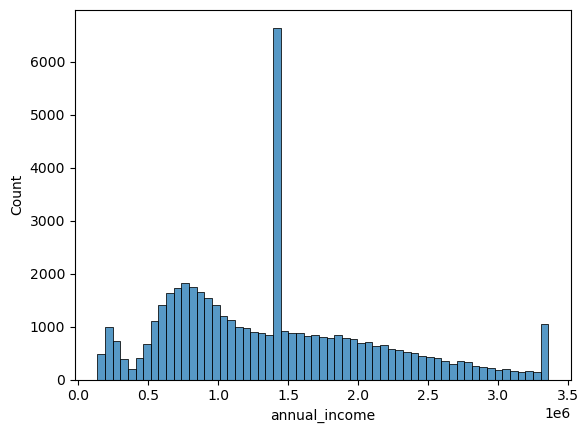

In [31]:
sns.histplot(df["annual_income"])

### Encoding Categorical Data

In [32]:
from sklearn.preprocessing import LabelEncoder
label_cols = [
    'personalized_offer',
    'holiday_campaign'
]
for col in label_cols:
    le = LabelEncoder()
    df.loc[:, col] = le.fit_transform(df[col])

In [33]:
df.loc[:, 'campaign_send_day'] = df['campaign_send_day'].replace({"Saturday" : "Weekend", "Sunday" : "Weekend"})

In [34]:
categorical_cols = [
    'gender',
    'marital_status',
    'education',
    'occupation',
    'city',
    'favorite_category',
    'campaign_channel',
    'campaign_type',
    'campaign_send_day',
    'favorite_category'
]

for col in categorical_cols:
    df.loc[:, col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

<Axes: xlabel='campaign_channel'>

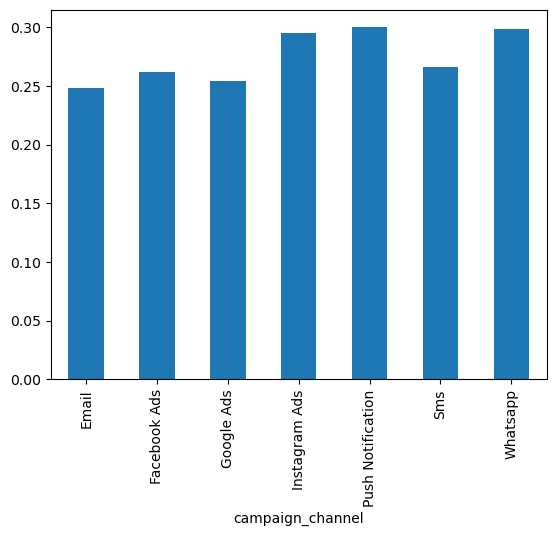

In [35]:
purchase_rate = pd.crosstab(
    df['campaign_channel'],
    df['purchased'],
    normalize='index'
)

purchase_rate[1].plot(kind='bar')

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers = [('encoder', OneHotEncoder(handle_unknown = "ignore", sparse_output = False), categorical_cols)],
    remainder = "passthrough"
)

transformed_data = ct.fit_transform(df)

encoded_feature_names = ct.named_transformers_['encoder'].get_feature_names_out(categorical_cols)

passthrough_cols = [col for col in df.columns if col not in categorical_cols]

all_new_columns = list(encoded_feature_names) + passthrough_cols

df = pd.DataFrame(transformed_data, columns = all_new_columns, index = df.index)

In [37]:
#Features were removed after considering redundancy, low feature importance, 
#correlation with existing variables, and minimal impact on validation performance
df = df.drop(["family_size", "pages_viewed", "cart_additions", "refund_requests", 
              "gender_Unspecified", "city_Unknown City", "recency_score", "frequency_score", 
              "monetary_score", "age"], axis=1)

In [50]:
print(df.columns.duplicated())

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False]


In [39]:
df = df.loc[:, ~df.columns.duplicated()]

In [40]:
df

,gender_Female,gender_Male,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed,education_Bachelor,education_Diploma,education_High School,education_Master,...,days_since_last_purchase,returned_orders,purchased,purchase_frequency,avg_monthly_spend,cart_abandonment_rate,purchase_conversion_rate,browsing_to_purchase_ratio,rfm_score,age_group
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,128,1,0,0.86,14567.65,0.038,1.333,2.52,14,30
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,164,0,0,0.18,109.88,0.6,0.143,29.0,4,20
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,74,5,1,1.2,5717.82,0.032,2.458,1.65,15,40
3,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,162,0,0,0.25,799.07,0.25,0.111,21.33,6,40
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,145,0,0,0.38,1189.47,0.091,0.76,5.7,9,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50495,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,107,2,1,0.6,2780.84,0.237,1.273,4.83,13,30
50496,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,156,0,1,0.39,1594.92,0.067,0.812,6.64,8,30
50497,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,119,4,1,0.59,755.45,0.163,1.842,2.64,11,30
50498,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,109,5,1,1.06,4711.84,0.018,2.75,0.75,15,40


In [41]:
df.to_csv('customer_propensity_processed_data', index = False)

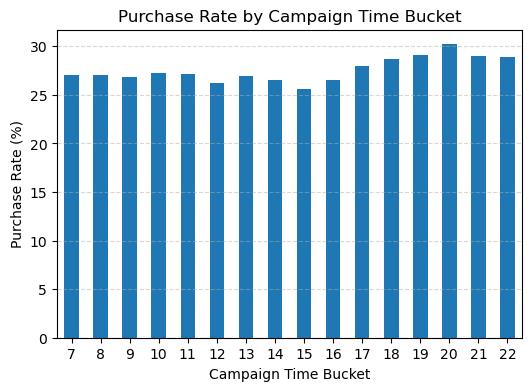

In [49]:
purchase_rate = pd.crosstab(
    df["campaign_send_hour"],
    df["purchased"],
    normalize="index"
) * 100

purchase_rate[1].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Purchase Rate by Campaign Time Bucket")
plt.xlabel("Campaign Time Bucket")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [43]:
def customer_segment(score):

    if score >= 13:
        return "Platinum"

    elif score >= 10:
        return "Gold"

    elif score >= 7:
        return "Silver"

    else:
        return "Bronze"

df["customer_segment"] = (
    df["rfm_score"]
      .apply(customer_segment)
)

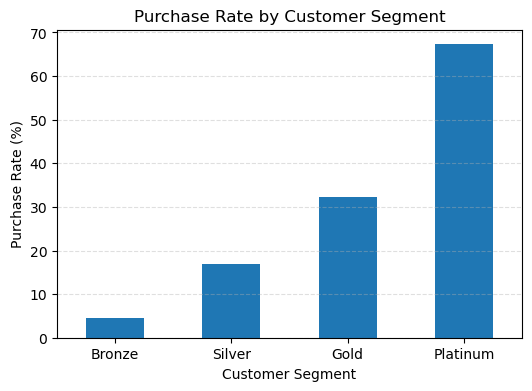

In [46]:
purchase_rate = (
    pd.crosstab(
        df["customer_segment"],
        df["purchased"],
        normalize="index"
    ) * 100
)

purchase_rate = purchase_rate.reindex(
    ["Bronze", "Silver", "Gold", "Platinum"]
)

purchase_rate[1].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Purchase Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()